# Matrix-Vector Multiplication

## Purpose

Understand matrix-vector multiplication as applying a transformation to a vector.

In the previous notebooks, we worked with vectors, dot products, cosine similarity, projections and components.

This notebook introduces the next idea:

> a matrix can transform a vector into another vector.

For now, we will use 2D vectors and 2×2 matrices because they are easy to calculate and plot.

## Helpers

These helpers keep the plotting code out of the main examples.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def setup_vector_plot(xlim=(-5, 5), ylim=(-5, 5), figsize=(5.5, 5.5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    return fig, ax


def draw_vector(
    ax,
    v,
    origin=(0, 0),
    label=None,
    label_offset=(0.1, 0.1),
    width=0.007,
):
    origin = np.array(origin, dtype=float)
    v = np.array(v, dtype=float)

    ax.quiver(
        origin[0],
        origin[1],
        v[0],
        v[1],
        angles="xy",
        scale_units="xy",
        scale=1,
        width=width,
    )

    if label:
        end = origin + v
        ax.text(
            end[0] + label_offset[0],
            end[1] + label_offset[1],
            label,
            fontsize=10,
        )


def draw_transformation(ax, original, transformed, original_label="v", transformed_label="A @ v"):
    draw_vector(ax, original, label=original_label, label_offset=(0.1, 0.1))
    draw_vector(ax, transformed, label=transformed_label, label_offset=(0.1, -0.35), width=0.01)

## A matrix can transform a vector

Here is a simple 2×2 matrix:

$$
A =
\begin{bmatrix}
2 & 0 \\
0 & 1
\end{bmatrix}
$$

This matrix doubles the x-component of a vector and leaves the y-component unchanged.

In [2]:
A = np.array([
    [2, 0],
    [0, 1],
])

v = np.array([2, 1])

transformed_v = A @ v

print("A:")
print(A)
print()
print("v:", v)
print("A @ v:", transformed_v)

A:
[[2 0]
 [0 1]]

v: [2 1]
A @ v: [4 1]


The result is another vector.

So in this notebook, we will think of a matrix as a **transformation rule**.

The expression:

$$
A @ v
$$

means:

> apply matrix \(A\) to vector \(v\)

## Calculating \(A @ v\)

Matrix-vector multiplication combines each row of the matrix with the vector.

For:

$$
A =
\begin{bmatrix}
2 & 0 \\
0 & 1
\end{bmatrix}
$$

and:

$$
v =
\begin{bmatrix}
2 \\
1
\end{bmatrix}
$$

we get:

$$
A v =
\begin{bmatrix}
2 \times 2 + 0 \times 1 \\
0 \times 2 + 1 \times 1
\end{bmatrix}
=
\begin{bmatrix}
4 \\
1
\end{bmatrix}
$$

In [3]:
manual_result = np.array([
    2 * v[0] + 0 * v[1],
    0 * v[0] + 1 * v[1],
])

numpy_result = A @ v

print("manual result:", manual_result)
print("NumPy result:", numpy_result)

manual result: [4 1]
NumPy result: [4 1]


## Plotting the original and transformed vector

The transformation is easier to understand visually.

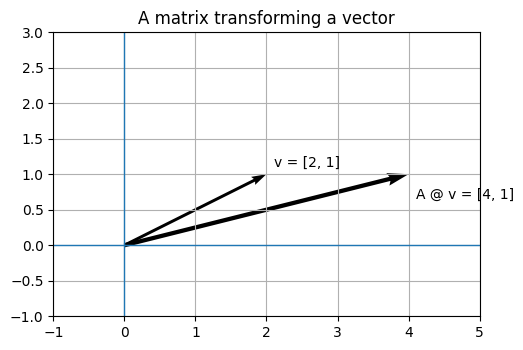

In [4]:
fig, ax = setup_vector_plot(xlim=(-1, 5), ylim=(-1, 3), figsize=(5.5, 4.5))

draw_transformation(ax, v, transformed_v, original_label="v = [2, 1]", transformed_label="A @ v = [4, 1]")

ax.set_title("A matrix transforming a vector")
plt.show()

The original vector was:

$$
v = [2, 1]
$$

After applying \(A\), the transformed vector is:

$$
A v = [4, 1]
$$

The x-component has doubled, while the y-component stayed the same.

## Trying another vector

The matrix is not just a rule for one vector.

It applies the same transformation to any compatible vector.

In [5]:
u = np.array([1.5, 2])
transformed_u = A @ u

print("u:", u)
print("A @ u:", transformed_u)

u: [1.5 2. ]
A @ u: [3. 2.]


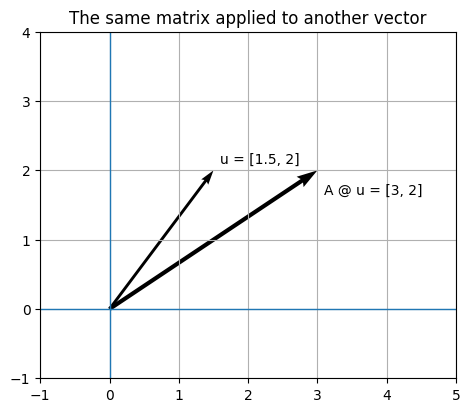

In [7]:
fig, ax = setup_vector_plot(xlim=(-1, 5), ylim=(-1, 4), figsize=(5.5, 4.5))

draw_transformation(ax, u, transformed_u, original_label="u = [1.5, 2]", transformed_label="A @ u = [3, 2]")

ax.set_title("The same matrix applied to another vector")
plt.show()

Again, the x-component doubled and the y-component stayed the same.

That is the transformation encoded by this matrix.

## Matrix-vector multiplication as a transformation rule

For this notebook, the important idea is:

> A matrix can be treated as a rule for moving vectors.

A 2×2 matrix transforms 2D vectors into 2D vectors.

The notation:

$$
A v
$$

means:

> transform vector \(v\) using matrix \(A\)

In NumPy, we write that as:

```python
A @ v
```

## Summary

- A matrix can transform a vector into another vector.
- A 2×2 matrix can transform 2D vectors.
- \(A v\) means applying matrix \(A\) to vector \(v\).
- In NumPy, matrix-vector multiplication uses `@`.
- The result of matrix-vector multiplication is another vector.

## Next step

Next, we will look at some simple transformations: scaling, reflection and shear.